# News Sentiment Audit (Guardian + NYT)

This notebook computes daily sentiment scores from the two news datasets in `Newsdata`:

- `guardian_trump_articles.csv`
- `nyt_trump_last_6_months.csv`

It prints key diagnostics and includes short commentary between steps.

In [1]:
from pathlib import Path
import re
from collections import defaultdict

import pandas as pd
import matplotlib.pyplot as plt
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

BASE_DIR = Path('.')
GUARDIAN_PATH = BASE_DIR / 'guardian_trump_articles.csv'
NYT_PATH = BASE_DIR / 'nyt_trump_last_6_months.csv'
OUT_CSV = BASE_DIR / 'sentiment_2025-11-14_to_2026-04-10.csv'
OUT_PLOT = BASE_DIR / 'news_sentiment_2025-11-14_to_2026-04-10.png'
START_DATE = pd.Timestamp('2025-11-14')
END_DATE = pd.Timestamp('2026-04-10')
TOKEN_PATTERN = re.compile(r"[a-z']+")

pd.set_option('display.max_rows', 20)
pd.set_option('display.max_columns', 20)

## 1) Load and combine the two news datasets

We normalize the date column and combine NYT + Guardian into one article-level table.

In [2]:
def load_news_source(path: Path, source_name: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    required = ['date', 'title', 'content']
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f'Missing columns in {path.name}: {missing}')

    out = df[required].copy()
    out['source'] = source_name
    out['date'] = pd.to_datetime(out['date'], errors='coerce', utc=True).dt.tz_convert(None).dt.normalize()
    out = out.dropna(subset=['date'])
    return out

guardian = load_news_source(GUARDIAN_PATH, 'guardian')
nyt = load_news_source(NYT_PATH, 'nyt')
news = pd.concat([guardian, nyt], ignore_index=True)

print(f'Combined rows: {len(news):,}')
print('Rows by source:')
print(news['source'].value_counts().to_string())
print(f'Date range (raw): {news["date"].min().date()} -> {news["date"].max().date()}')
news.head(3)

Combined rows: 10,960
Rows by source:
source
guardian    7383
nyt         3577
Date range (raw): 2025-11-01 -> 2026-04-17


,date,title,content,source
0,2025-11-01,Trump news at a glance: Friday rulings hamper ...,President Trump received a trio of legal setba...,guardian
1,2025-11-01,‘It is the scariest of times’: Margaret Atwood...,Margaret Atwood is doing her grocery shopping ...,guardian
2,2025-11-01,Xi Jinping’s moment and whirlwind diplomatic t...,The leaders of countries across the Asia-Pacif...,guardian


### Quick comment
The combined table is article-level data. Next we compute sentiment per article and aggregate to daily metrics.

## 2) Compute article sentiment and daily features

In [3]:
analyzer = SentimentIntensityAnalyzer()

news = news.copy()
news['text'] = (
    news['title'].fillna('').astype(str).str.strip()
    + '. ' +
    news['content'].fillna('').astype(str).str.strip()
)
news['sentiment_article'] = news['text'].apply(lambda x: analyzer.polarity_scores(x)['compound'] if x else 0.0)

daily = (
    news.groupby('date', as_index=False)
    .agg(
        sentiment_mean=('sentiment_article', 'mean'),
        sentiment_std=('sentiment_article', 'std'),
        sentiment_pct_negative=('sentiment_article', lambda x: (x < -0.5).mean()),
        n_articles=('sentiment_article', 'size')
    )
    .rename(columns={'date': 'post_date'})
    .sort_values('post_date')
    .reset_index(drop=True)
)
daily['sentiment_std'] = daily['sentiment_std'].fillna(0.0)

daily = daily[(daily['post_date'] >= START_DATE) & (daily['post_date'] <= END_DATE)].copy()
daily['sentiment_roll7'] = daily['sentiment_mean'].rolling(7, min_periods=1).mean()

print(f'Rows (days): {len(daily):,}')
print(f'Date range  : {daily["post_date"].min().date()} -> {daily["post_date"].max().date()}')
daily.head(5)

Rows (days): 148
Date range  : 2025-11-14 -> 2026-04-10


,post_date,sentiment_mean,sentiment_std,sentiment_pct_negative,n_articles,sentiment_roll7
13,2025-11-14,0.104176,0.804508,0.352113,71,0.104176
14,2025-11-15,-0.091593,0.783690,0.418605,43,0.006292
15,2025-11-16,-0.034895,0.841784,0.405405,37,-0.007437
16,2025-11-17,0.021648,0.740388,0.333333,66,-0.000166
17,2025-11-18,-0.052819,0.814025,0.404762,84,-0.010696


### Quick comment
- `sentiment_mean` is the daily average sentiment score.
- `sentiment_roll7` smooths short-term noise.
- `n_articles` helps interpret whether extreme values came from low/high article volume.

## 3) Print summary and top/bottom days

In [4]:
print('Summary statistics:')
display(daily[['sentiment_mean', 'sentiment_std', 'sentiment_pct_negative', 'n_articles']].describe().round(4))

print('Top 5 most positive days:')
display(daily.nlargest(5, 'sentiment_mean')[['post_date', 'n_articles', 'sentiment_mean']])

print('Top 5 most negative days:')
display(daily.nsmallest(5, 'sentiment_mean')[['post_date', 'n_articles', 'sentiment_mean']])

corr = (
    daily[['n_articles', 'sentiment_mean', 'sentiment_std', 'sentiment_pct_negative']]
    .corr(numeric_only=True)
    .loc['n_articles', ['sentiment_mean', 'sentiment_std', 'sentiment_pct_negative']]
    .round(4)
)
print('Correlation with n_articles:')
print(corr.to_string())

Summary statistics:


,sentiment_mean,sentiment_std,sentiment_pct_negative,n_articles
count,148.0000,148.0000,148.0000,148.0000
mean,-0.1195,0.7994,0.4536,66.0338
std,0.1719,0.0437,0.1067,22.3419
min,-0.5714,0.6458,0.2333,20.0000
25%,-0.2242,0.7721,0.3873,47.5000
50%,-0.1141,0.8027,0.4482,69.0000
75%,-0.0100,0.8301,0.5239,83.0000
max,0.4212,0.9145,0.7292,133.0000


Top 5 most positive days:


,post_date,n_articles,sentiment_mean
61,2026-01-01,30,0.421207
57,2025-12-28,20,0.246690
111,2026-02-20,100,0.179526
42,2025-12-13,39,0.177408
106,2026-02-15,36,0.172547


Top 5 most negative days:


,post_date,n_articles,sentiment_mean
127,2026-03-08,48,-0.571383
121,2026-03-02,92,-0.541072
122,2026-03-03,99,-0.514112
128,2026-03-09,66,-0.494177
131,2026-03-12,66,-0.483930


Correlation with n_articles:
sentiment_mean           -0.0885
sentiment_std            -0.2888
sentiment_pct_negative    0.0068


### Quick comment
Use the `n_articles` correlation carefully — sentiment can shift from true tone changes and from changes in topic mix across days.

## 4) Word-level drivers on top positive/negative days

In [5]:
def aggregate_sentiment_words(texts: pd.Series, positive: bool) -> pd.DataFrame:
    counts = defaultdict(int)
    contribution = defaultdict(float)

    for text in texts.dropna().astype(str):
        for token in TOKEN_PATTERN.findall(text.lower()):
            score = analyzer.lexicon.get(token)
            if score is None or score == 0:
                continue
            if positive and score > 0:
                counts[token] += 1
                contribution[token] += score
            elif (not positive) and score < 0:
                counts[token] += 1
                contribution[token] += score

    word_df = pd.DataFrame({
        'word': list(counts.keys()),
        'count': [counts[w] for w in counts],
        'total_lexicon_contribution': [contribution[w] for w in counts],
    })

    if word_df.empty:
        return word_df

    if positive:
        word_df = word_df.sort_values(['total_lexicon_contribution', 'count'], ascending=[False, False])
    else:
        word_df = word_df.sort_values(['total_lexicon_contribution', 'count'], ascending=[True, False])

    return word_df.reset_index(drop=True)

top_days = 5
top_words = 15

pos_days = daily.nlargest(top_days, 'sentiment_mean')['post_date']
neg_days = daily.nsmallest(top_days, 'sentiment_mean')['post_date']

pos_words = aggregate_sentiment_words(news[news['date'].isin(pos_days)]['text'], positive=True).head(top_words)
neg_words = aggregate_sentiment_words(news[news['date'].isin(neg_days)]['text'], positive=False).head(top_words)

print('Positive-day word drivers:')
display(pos_words)

print('Negative-day word drivers:')
display(neg_words)

Positive-day word drivers:


,word,count,total_lexicon_contribution
0,peace,161,402.5
1,like,252,378.0
2,great,89,275.9
3,security,195,273.0
4,united,148,266.4
5,good,136,258.4
6,best,78,249.6
7,won,92,248.4
8,justice,95,228.0
9,intelligence,105,220.5


Negative-day word drivers:


,word,count,total_lexicon_contribution
0,war,1363,-3952.7
1,killed,435,-1522.5
2,strikes,691,-1036.5
3,attacks,534,-1014.6
4,attack,483,-1014.3
5,no,623,-747.6
6,crisis,199,-616.9
7,conflict,472,-613.6
8,threat,224,-537.6
9,crude,185,-499.5


### Quick comment
These are lexicon-based contributors (VADER dictionary matches), so they are interpretable but still context-limited for political text.

## 5) Plot + export

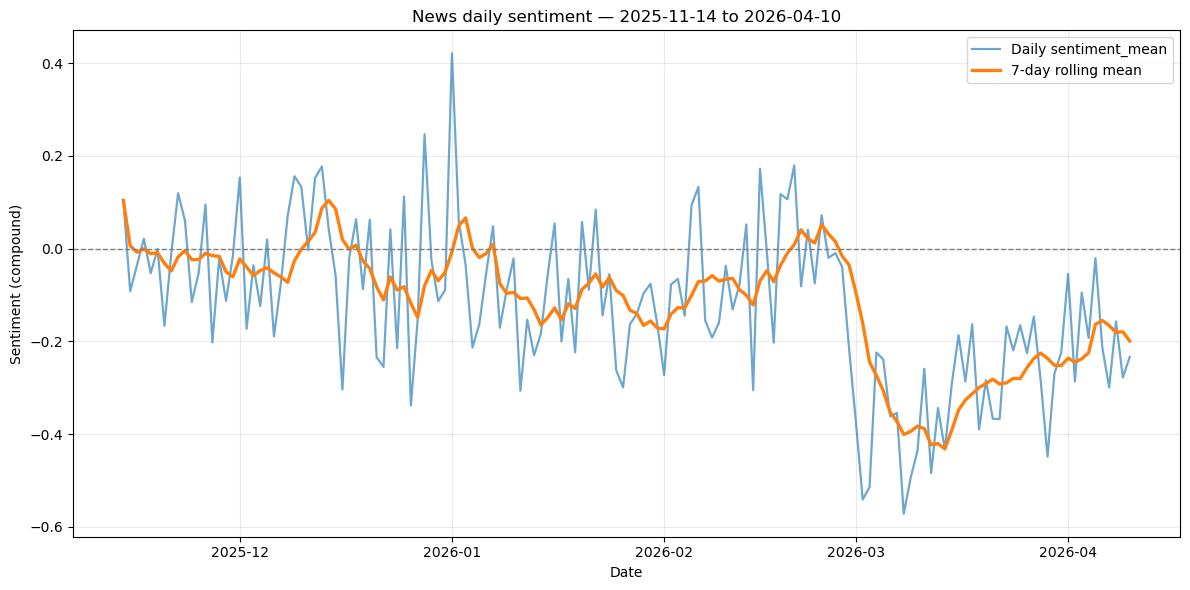

Saved CSV : /Users/christofferfrost/Documents/GitHub/advanced_business_analytics/Newsdata/sentiment_2025-11-14_to_2026-04-10.csv
Saved plot: /Users/christofferfrost/Documents/GitHub/advanced_business_analytics/Newsdata/news_sentiment_2025-11-14_to_2026-04-10.png


In [6]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(daily['post_date'], daily['sentiment_mean'], label='Daily sentiment_mean', linewidth=1.6, alpha=0.65)
ax.plot(daily['post_date'], daily['sentiment_roll7'], label='7-day rolling mean', linewidth=2.4)
ax.axhline(0, color='grey', linestyle='--', linewidth=1)
ax.set_title(f"News daily sentiment — {daily['post_date'].min().date()} to {daily['post_date'].max().date()}")
ax.set_xlabel('Date')
ax.set_ylabel('Sentiment (compound)')
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

daily[['post_date', 'sentiment_mean', 'sentiment_roll7']].to_csv(OUT_CSV, index=False)
fig.savefig(OUT_PLOT, dpi=180)

print(f'Saved CSV : {OUT_CSV.resolve()}')
print(f'Saved plot: {OUT_PLOT.resolve()}')